# Relaxation Step
This example is designed to evaluate the accuracy of our membrane force calculation using the coordinates of a parabolic function. Specifically, it examines how well the original force distribution can be recovered when small noise is added to the initial coordinates. The process is outlined as follows:

1. Sample `N_node` coordinate from the parabola function, $y = h x^2$. Add Gaussian noise, $\mathcal{N}(0, \sigma_\mathrm{noise})$, to every sampled point in both $x$ and $y$ directions. 
2. Based on the sampled points, interpolate the curve using B-spline function. Resample `n_vertices` points evenly from the interpolated curve. The interpolation is done by minimizing the following objective function, $J = \sum^N (y_i - S(x_i))^2 + s \cdot R(S)$. Here, $(x_i, y_i)$ is the originally sampled coordinate, $S$ is the B-spline function, and $R(S) = \int (S'')^2 ds$ is the smoothing term.
3. Relax the curve based on the custom membrane energy, $E = E_\mathrm{bend} + E_\mathrm{surf} + E_\mathrm{reg}$. Here, $E_\mathrm{bend} = \kappa_b \int_C H^2 ds$ is the bending energy, $E_\mathrm{surf} = \sigma \int_C ds$ is the surface energy, and $E_\mathrm{reg} = \kappa_r \sum (\frac{\Delta s - \langle \Delta s \rangle}{\langle \Delta s \rangle})^2$ is the regularization energy. The relaxation was performed by forward Eulear method.
4. Calculated the membrane force, $\vec{f}_i = \partial E_\mathrm{mem}/\partial \vec{r}_i$, based on a membrane energy, $E_\mathrm{mem} = E_\mathrm{bend} + E_\mathrm{surf}$. The partial derivative was numerically solved by JAX auto-diff.

## Individual data aquisition and analysis
This block performs the relaxation of the curve and store data in dat/v2/data_scale.

In [22]:
# Parabola with noise

from sample import make_parabola
from variation_relax import resample, relax_bending, relax_bending_log
import os
import numpy as np

## Parameters ##
N_node = 30        # number of vertices on the original parabola
L_etoe = 100       # end-to-end distance of the parabola
height = 50        # height of the parabola
noise_level = 0.1  # noise added to the oridinal parabola coordinate
N_sample = N_node
n_degree = 8       # degree of the data fidelity term (CHANGE SOURCE CODE ACCORDINGLY)
k_d = 0.1          # coefficient for the data fidelity term


# Calculating the original parabola coordinate with noise
ori_coords = make_parabola(N_node = N_node, L_etoe = L_etoe, height = height, point_dist = "unif", noise_level = noise_level)
# ori_coords = ori_coords[ori_coords[:, 0].argsort()]

params = {
    "Kb"      : 10,       # bending term weight
    "Ks"      : 10,       # surface tension term weight
    "Kr"      : 10,       # regularization term weight
    "k_d"     : k_d,      # data fidelity term weight
    "dist_c"  : 0.1,      # cutoff distance for data term
    "dt"      : 1e-4,     # time step for forward Eulear
    "n_iter"  : int(2e5), # total iteration of forward Eulear
    "boundary": "pinned", # boundary condition
    "del_save": 1e3,
}

# Relax the curve by forward Eulear based on membrane energy
# relaxed_coords = relax_bending(coords=spl_coords, data_points=ori_coords, **params)
coords, energy, forces, length, curvat, dtdist = relax_bending_log(coords=ori_coords, data_points=ori_coords, **params)

# Storing data
file_path = f"dat/v2/data_scale/k{k_d}_n{n_degree}_s{noise_level:.2f}".replace('.', '') + ".npz"
np.savez(file_path, ori_coords = ori_coords, coords = coords, energy=energy, forces=forces, length=length, curvat=curvat, dtdist=dtdist)



kappa:  1119.6261710287079
sigma:  0.06765747201444265


Energy relaxation:   0%|          | 0/500000 [00:00<?, ?it/s]

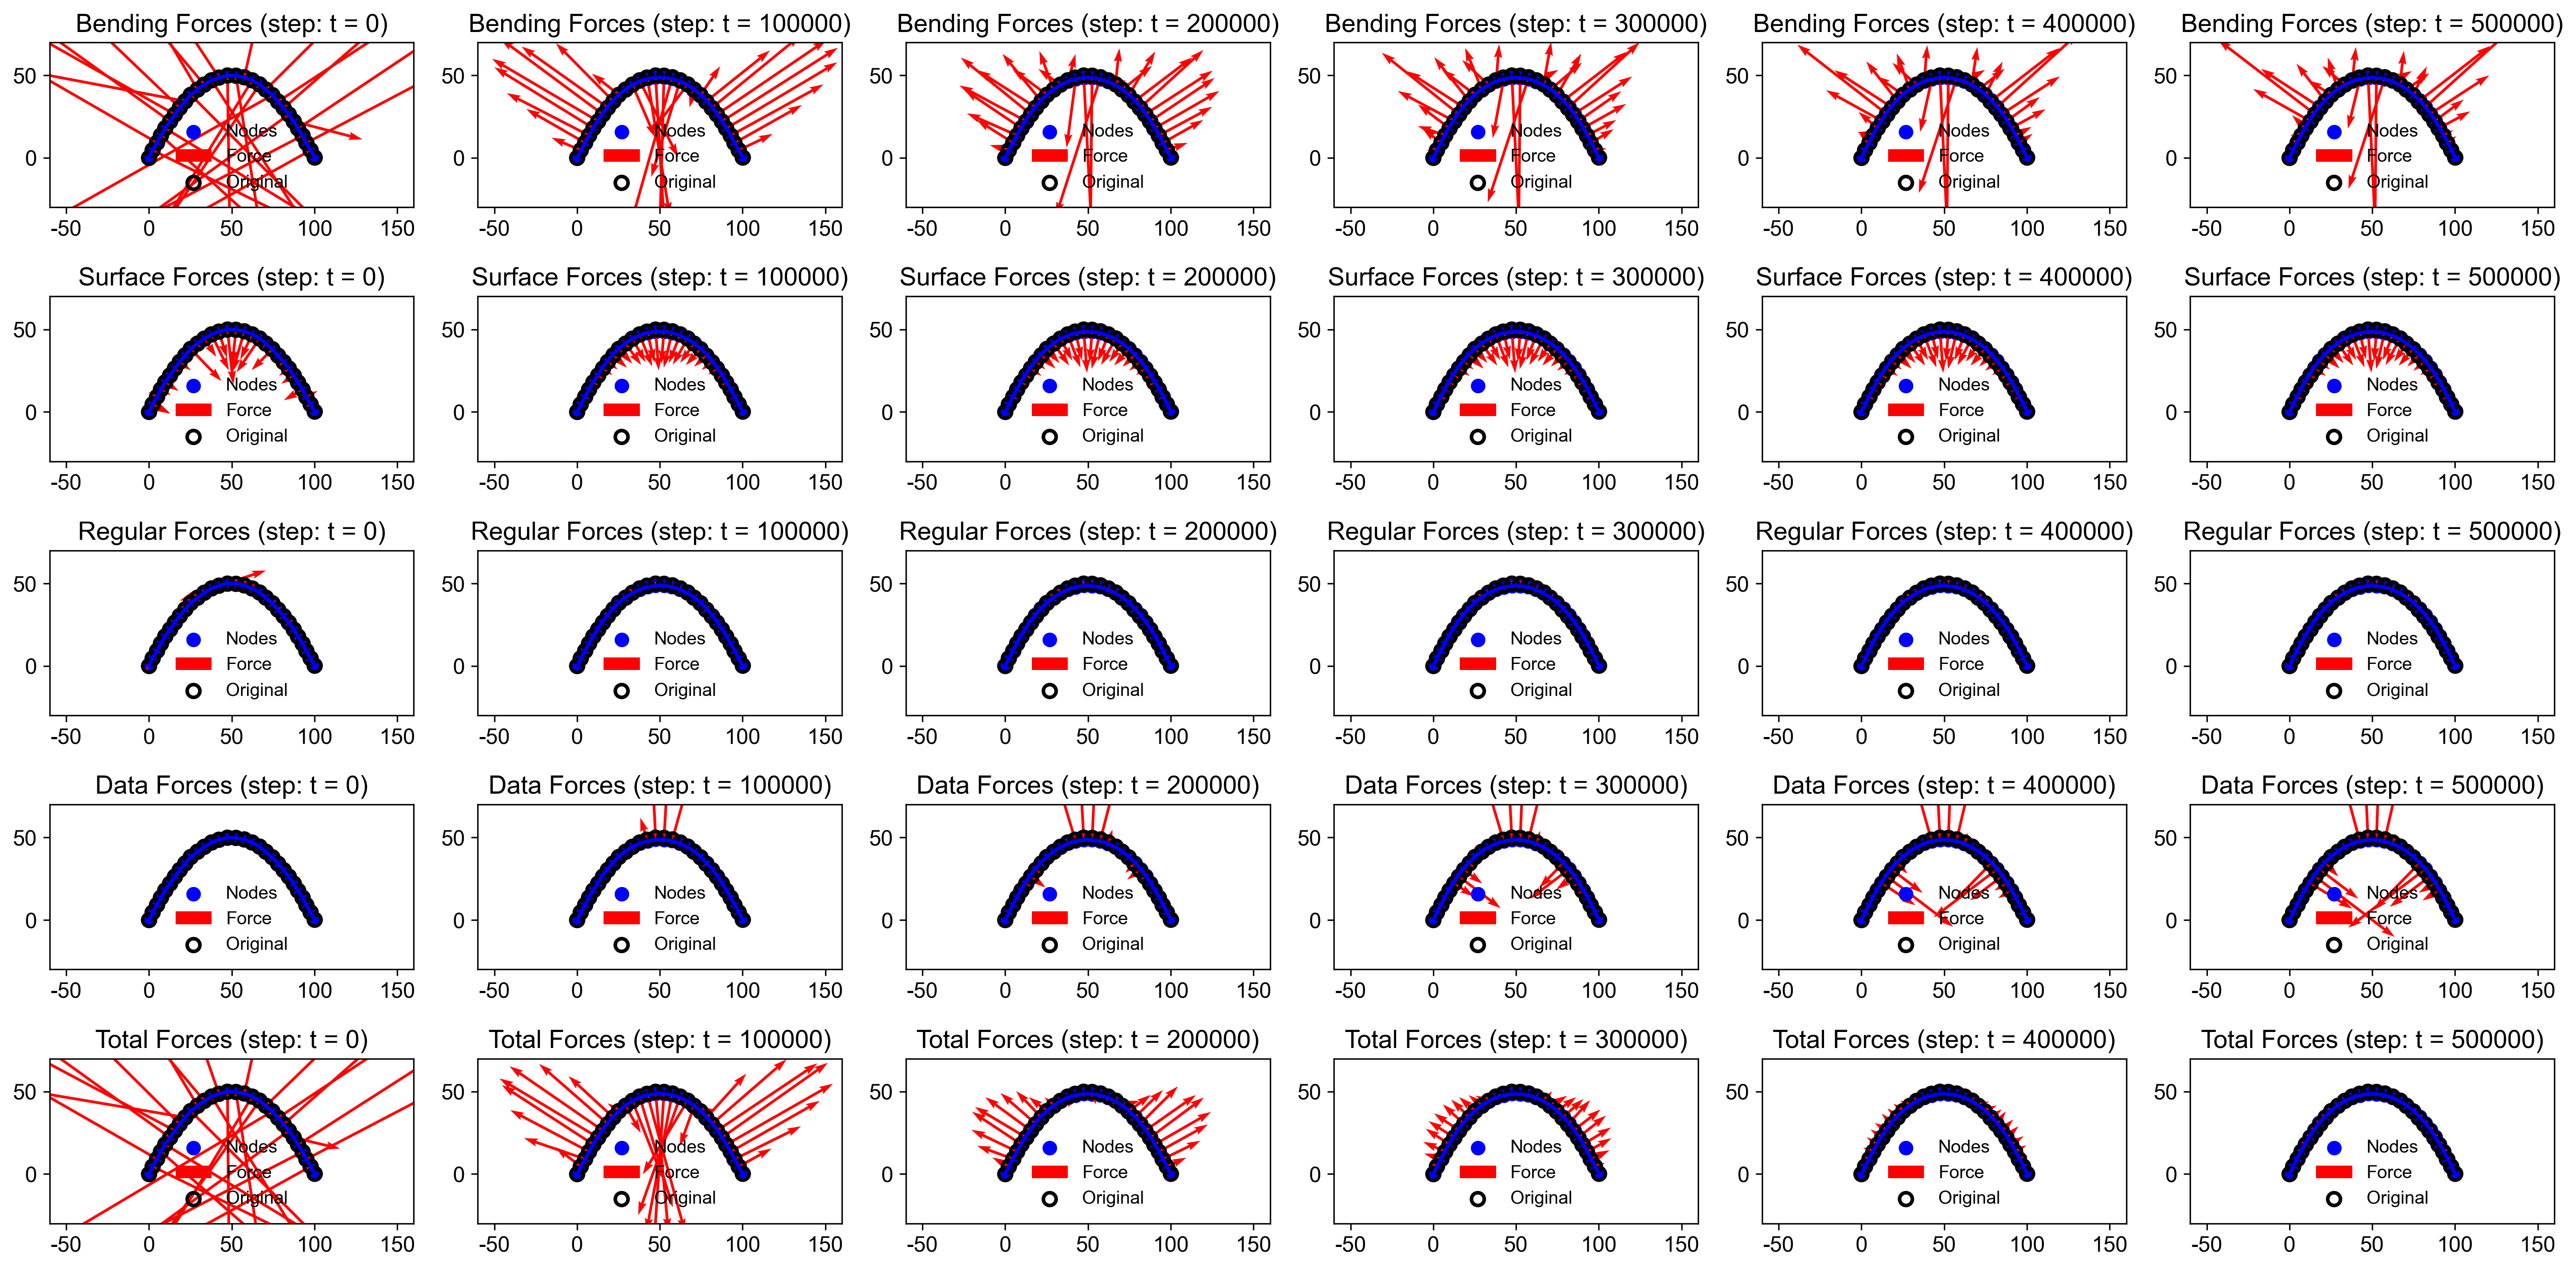

In [23]:
# Progress of the force field during relaxation

import matplotlib.pyplot as plt
import numpy as np
import os
from sample import plot_parabola_ax

# k_d = 10
# n_degree = 4
# noise_level = 0.1

# tot_iter = 1e5
# del_show = 2e4
tot_iter = 2e5
del_show = 4e4
# tot_iter = 5e5
# del_show = 1e5
del_save = 1e3

interval = int(del_show/del_save)
n_show = int(tot_iter/del_show)+1
fig, axes = plt.subplots(5, n_show, figsize=(20, 10))

file_path = f"dat/v2/data_scale/k{k_d}_n{n_degree}_s{noise_level:.2f}".replace('.', '') + ".npz"
data = np.load(file_path)
ori_coords = data['ori_coords']
coords = data['coords']
energy = data['energy']
forces = data['forces']

for idx in range(0, n_show):

    n_iter = del_show * idx
    i = interval * idx
    total_forces = forces[i, 0] + forces[i, 1] + forces[i, 2] + forces[i, 3]

    scale = 10
    
    plot_parabola_ax(coords[i], forces[i, 0], ax=axes[0, idx], n_iter=n_iter, force_type="Bending Forces", scale=scale, ori_coords = ori_coords)
    plot_parabola_ax(coords[i], forces[i, 1], ax=axes[1, idx], n_iter=n_iter, force_type="Surface Forces", scale=scale, ori_coords = ori_coords)
    plot_parabola_ax(coords[i], forces[i, 2], ax=axes[2, idx], n_iter=n_iter, force_type="Regular Forces", scale=scale, ori_coords = ori_coords)
    plot_parabola_ax(coords[i], forces[i, 3], ax=axes[3, idx], n_iter=n_iter, force_type="Data Forces", scale=scale, ori_coords = ori_coords)
    plot_parabola_ax(coords[i], total_forces, ax=axes[4, idx], n_iter=n_iter, force_type="Total Forces", scale=scale, ori_coords = ori_coords)

plt.tight_layout()
# plt.savefig(f"figures/spline_test/force_n{N_node}_{noise_level:.2f}".replace('.', '')+ f"_n{n_vertices:03d}_k{k_val}.png", dpi=300)
plt.show()


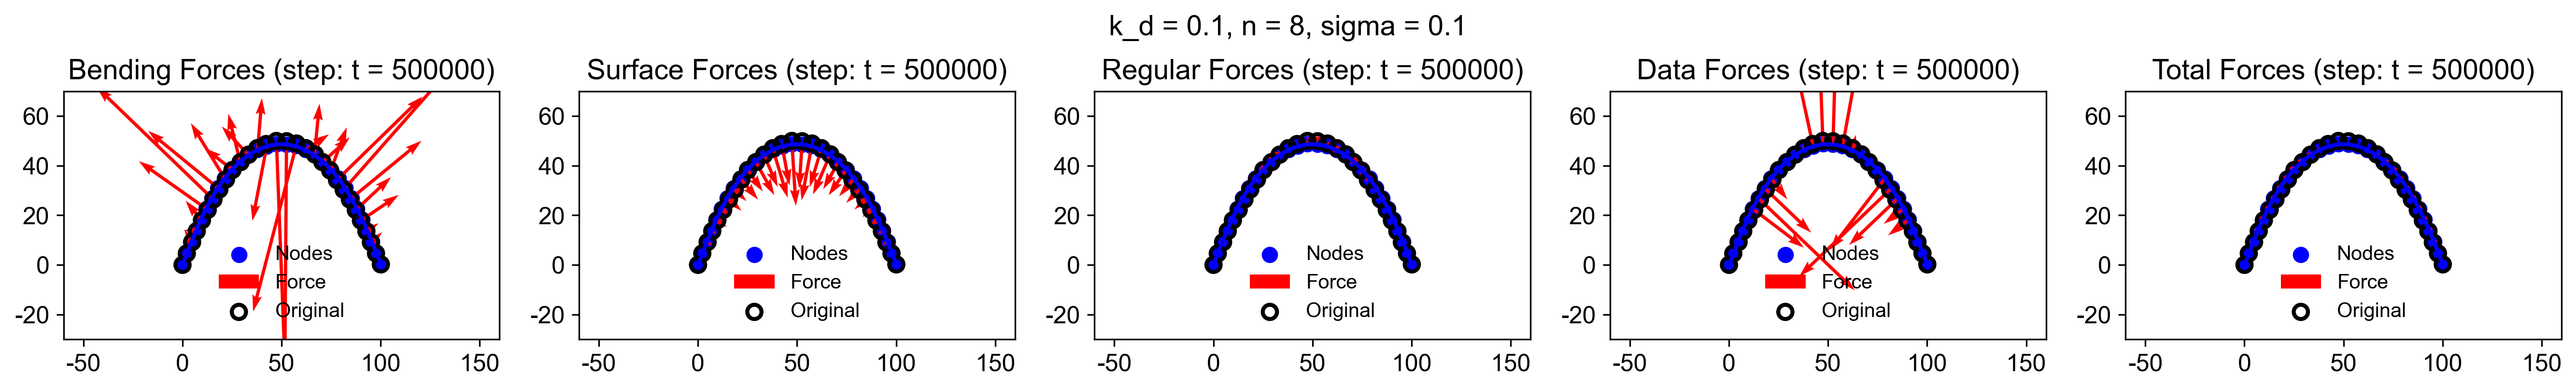

In [24]:
# Force field after relaxation

import matplotlib.pyplot as plt
import numpy as np
import os
from sample import plot_parabola_ax

# k_d = 10
# n_degree = 4
# noise_level = 0.1


n_iter = 2e5
# n_iter = 5e5

file_path = f"dat/v2/data_scale/k{k_d}_n{n_degree}_s{noise_level:.2f}".replace('.', '') + ".npz"
data = np.load(file_path)
ori_coords = data['ori_coords']
coords = data['coords']
energy = data['energy']
forces = data['forces']


fig, axes = plt.subplots(1, 5, figsize=(18, 3))
total_forces = forces[-1, 0] + forces[-1, 1] + forces[-1, 2] + forces[-1, 3]
scale = 10
plot_parabola_ax(coords[-1], forces[-1, 0], ax=axes[0], n_iter=n_iter, force_type="Bending Forces", scale=scale, ori_coords = ori_coords)
plot_parabola_ax(coords[-1], forces[-1, 1], ax=axes[1], n_iter=n_iter, force_type="Surface Forces", scale=scale, ori_coords = ori_coords)
plot_parabola_ax(coords[-1], forces[-1, 2], ax=axes[2], n_iter=n_iter, force_type="Regular Forces", scale=scale, ori_coords = ori_coords)
plot_parabola_ax(coords[-1], forces[-1, 3], ax=axes[3], n_iter=n_iter, force_type="Data Forces", scale=scale, ori_coords = ori_coords)
plot_parabola_ax(coords[-1], total_forces , ax=axes[4], n_iter=n_iter, force_type="Total Forces", scale=scale, ori_coords = ori_coords)

fig.suptitle(f"k_d = {k_d}, n = {n_degree}, sigma = {noise_level}", y=0.9)

plt.tight_layout()
plt.savefig(f"figures/v2/data_scale/force_k{k_d}_n{n_degree}_s{noise_level:.2f}".replace('.',''), dpi=300)
plt.show()

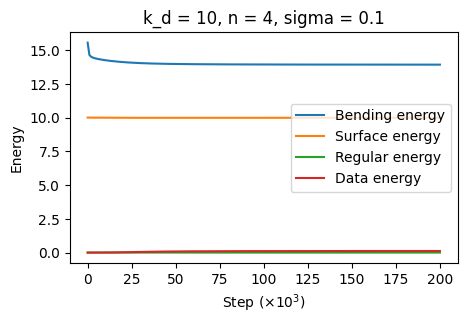

In [4]:
# Energy progress during relaxation

import numpy as np
import matplotlib.pyplot as plt
import os

k_d = 10
n_degree = 4
noise_level = 0.1

file_path = f"dat/v2/data_scale/k{k_d}_n{n_degree}_s{noise_level:.2f}".replace('.', '') + ".npz"
data = np.load(file_path)
energy = data['energy']

plt.figure(figsize=(5, 3))

energy_sum = energy.sum(axis=1)

# plt.plot((energy[:, 0] - np.min(energy[:, 0])) / (np.max(energy[:, 0]) - np.min(energy[:, 0])), label=f'Bending energy')
# plt.plot((energy[:, 1] - np.min(energy[:, 1])) / (np.max(energy[:, 1]) - np.min(energy[:, 1])), label=f'Surface energy')
# plt.plot((energy[:, 2] - np.min(energy[:, 2])) / (np.max(energy[:, 2]) - np.min(energy[:, 2])), label=f'Regular energy')
# plt.plot((energy[:, 3] - np.min(energy[:, 3])) / (np.max(energy[:, 3]) - np.min(energy[:, 3])), label=f'Data energy')
# plt.plot((energy_sum   - np.min(energy_sum  )) / (np.max(energy_sum  ) - np.min(energy_sum  )), label=f'Total energy')

plt.plot(energy[:, 0], label=f'Bending energy')
plt.plot(energy[:, 1], label=f'Surface energy')
plt.plot(energy[:, 2], label=f'Regular energy')
plt.plot(energy[:, 3], label=f'Data energy')
# plt.plot(energy_sum  , label=f'Total energy')

plt.title(f"k_d = {k_d}, n = {n_degree}, sigma = {noise_level}")
plt.xlabel(r"Step ($\times 10^3$)")
# plt.ylabel('Normalized Energy')
plt.ylabel('Energy')
plt.legend()
# plt.savefig(f"figures/v2/data_scale/energy_k{k_d}_n{n_degree}_s{noise_level:.2f}.".replace('.', ''), dpi=300, bbox_inches='tight')
plt.show()


## Collective analysis
In this block, we use the collection of data for the scaling analysis

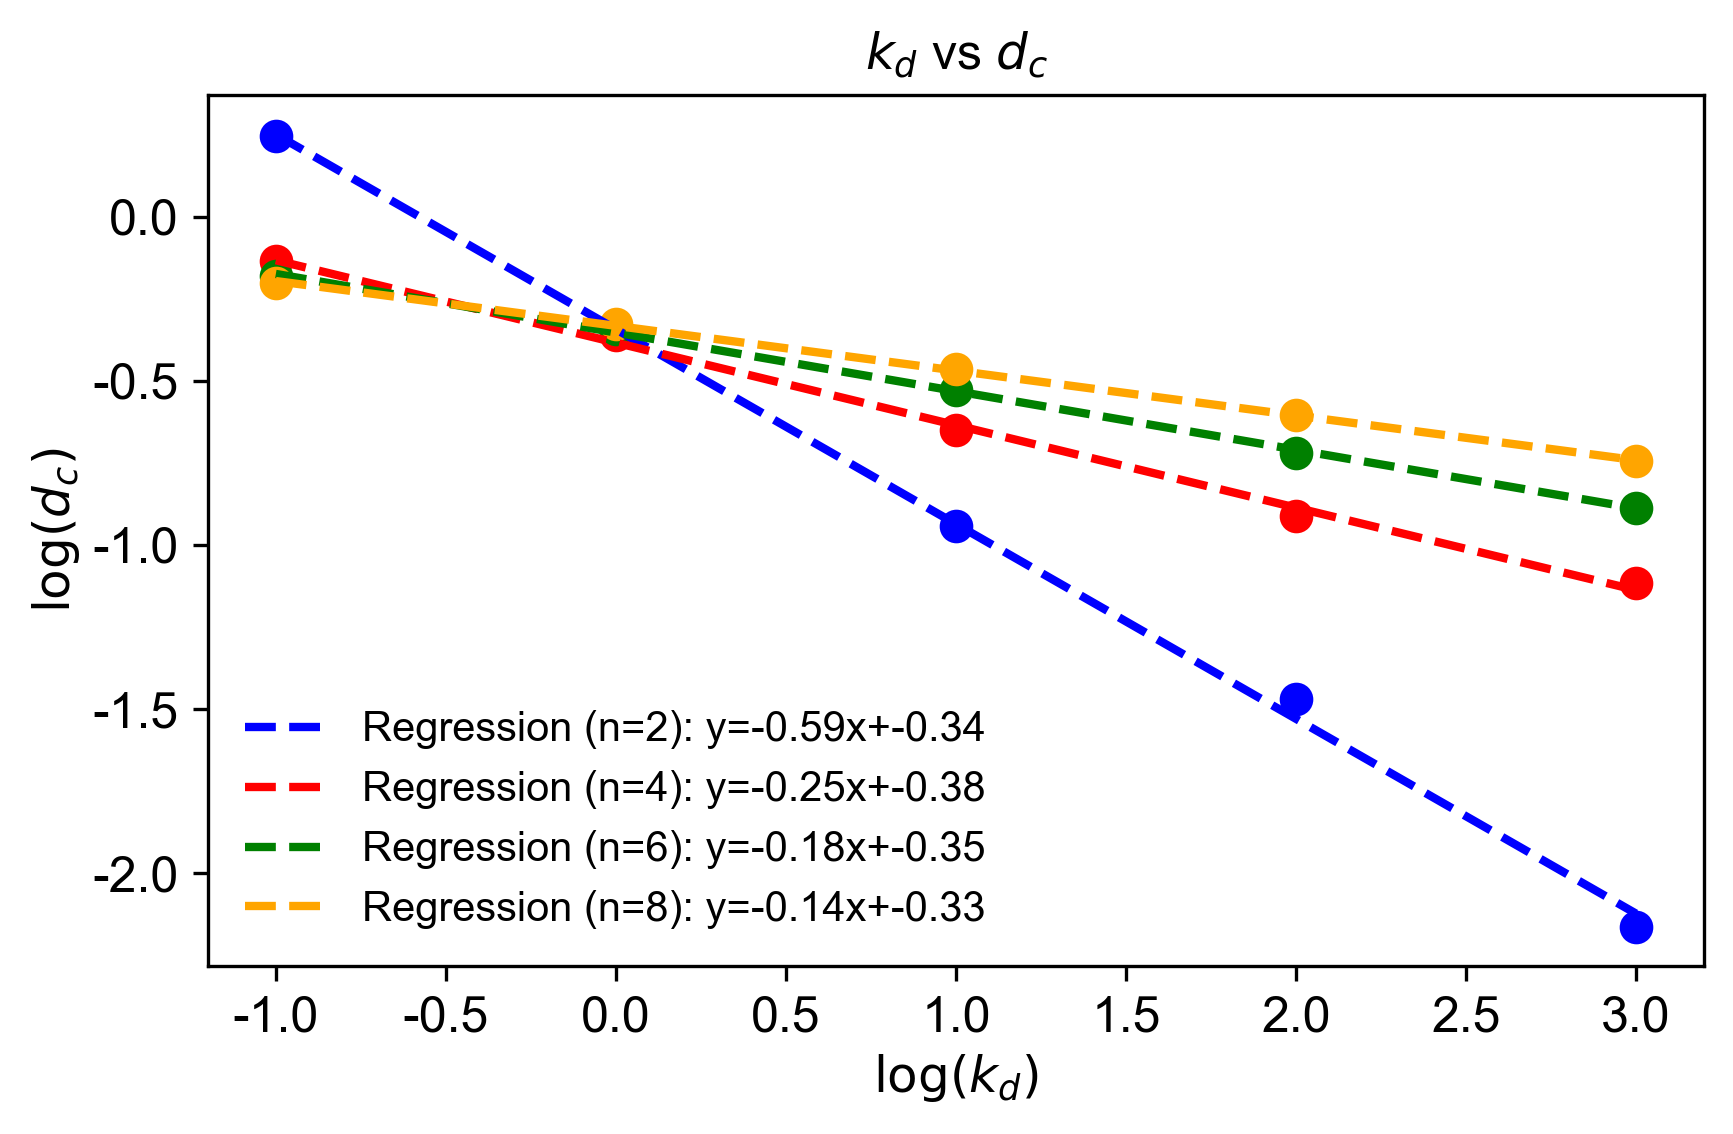

In [37]:
# k_d vs data distance

import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import linregress

k_d_list = [0.1, 1, 10, 100, 1000]
noise_level = 0.1

def calculate_regression(n_degree):
    dist_last_array = []
    
    for k_d in k_d_list:
        file_path = f"dat/v2/data_scale/k{k_d}_n{n_degree}_s{noise_level:.2f}".replace('.', '') + ".npz"
        data = np.load(file_path)
        dtdist = data['dtdist']
        dist_mean = dtdist.mean(axis=1)
        # dist_mean = dtdist.max(axis=1)
        dist_last = dist_mean[-1]
        dist_last_array.append(dist_last)

    log_k_d = np.log10(k_d_list)
    log_d_c = np.log10(dist_last_array)
    slope, intercept, r_value, p_value, std_err = linregress(log_k_d, log_d_c)
    regression_line = slope * log_k_d + intercept
    
    return log_k_d, log_d_c, regression_line, slope, intercept


log_k_d_2, log_d_c_2, regression_line_2, slope_2, intercept_2 = calculate_regression(n_degree=2)
log_k_d_4, log_d_c_4, regression_line_4, slope_4, intercept_4 = calculate_regression(n_degree=4)
log_k_d_6, log_d_c_6, regression_line_6, slope_6, intercept_6 = calculate_regression(n_degree=6)
log_k_d_8, log_d_c_8, regression_line_8, slope_8, intercept_8 = calculate_regression(n_degree=8)  


plt.figure(figsize=(6, 4))

# Plot data and regression for n_degree = 2
plt.scatter(log_k_d_2, log_d_c_2, color='blue', s=50)
plt.plot(log_k_d_2, regression_line_2, color='blue', linestyle='--', 
         label=f"Regression (n=2): y={slope_2:.2f}x+{intercept_2:.2f}")

# Plot data and regression for n_degree = 4
plt.scatter(log_k_d_4, log_d_c_4, color='red', s=50)
plt.plot(log_k_d_4, regression_line_4, color='red', linestyle='--', 
         label=f"Regression (n=4): y={slope_4:.2f}x+{intercept_4:.2f}")

# Plot data and regression for n_degree = 6
plt.scatter(log_k_d_6, log_d_c_6, color='green', s=50)
plt.plot(log_k_d_6, regression_line_6, color='green', linestyle='--', 
         label=f"Regression (n=6): y={slope_6:.2f}x+{intercept_6:.2f}")

# Plot data and regression for n_degree = 8
plt.scatter(log_k_d_8, log_d_c_8, color='orange', s=50)
plt.plot(log_k_d_8, regression_line_8, color='orange', linestyle='--', 
         label=f"Regression (n=8): y={slope_8:.2f}x+{intercept_8:.2f}")      

plt.xlabel(r"$\log(k_d)$", fontsize=12)
plt.ylabel(r"$\log(d_c)$", fontsize=12)
plt.title(r"$k_d$ vs $d_c$", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(f"figures/v2/data_scale/kd_vs_dc_s{noise_level:.2f}.".replace('.', ''), dpi=300, bbox_inches='tight')
plt.show()



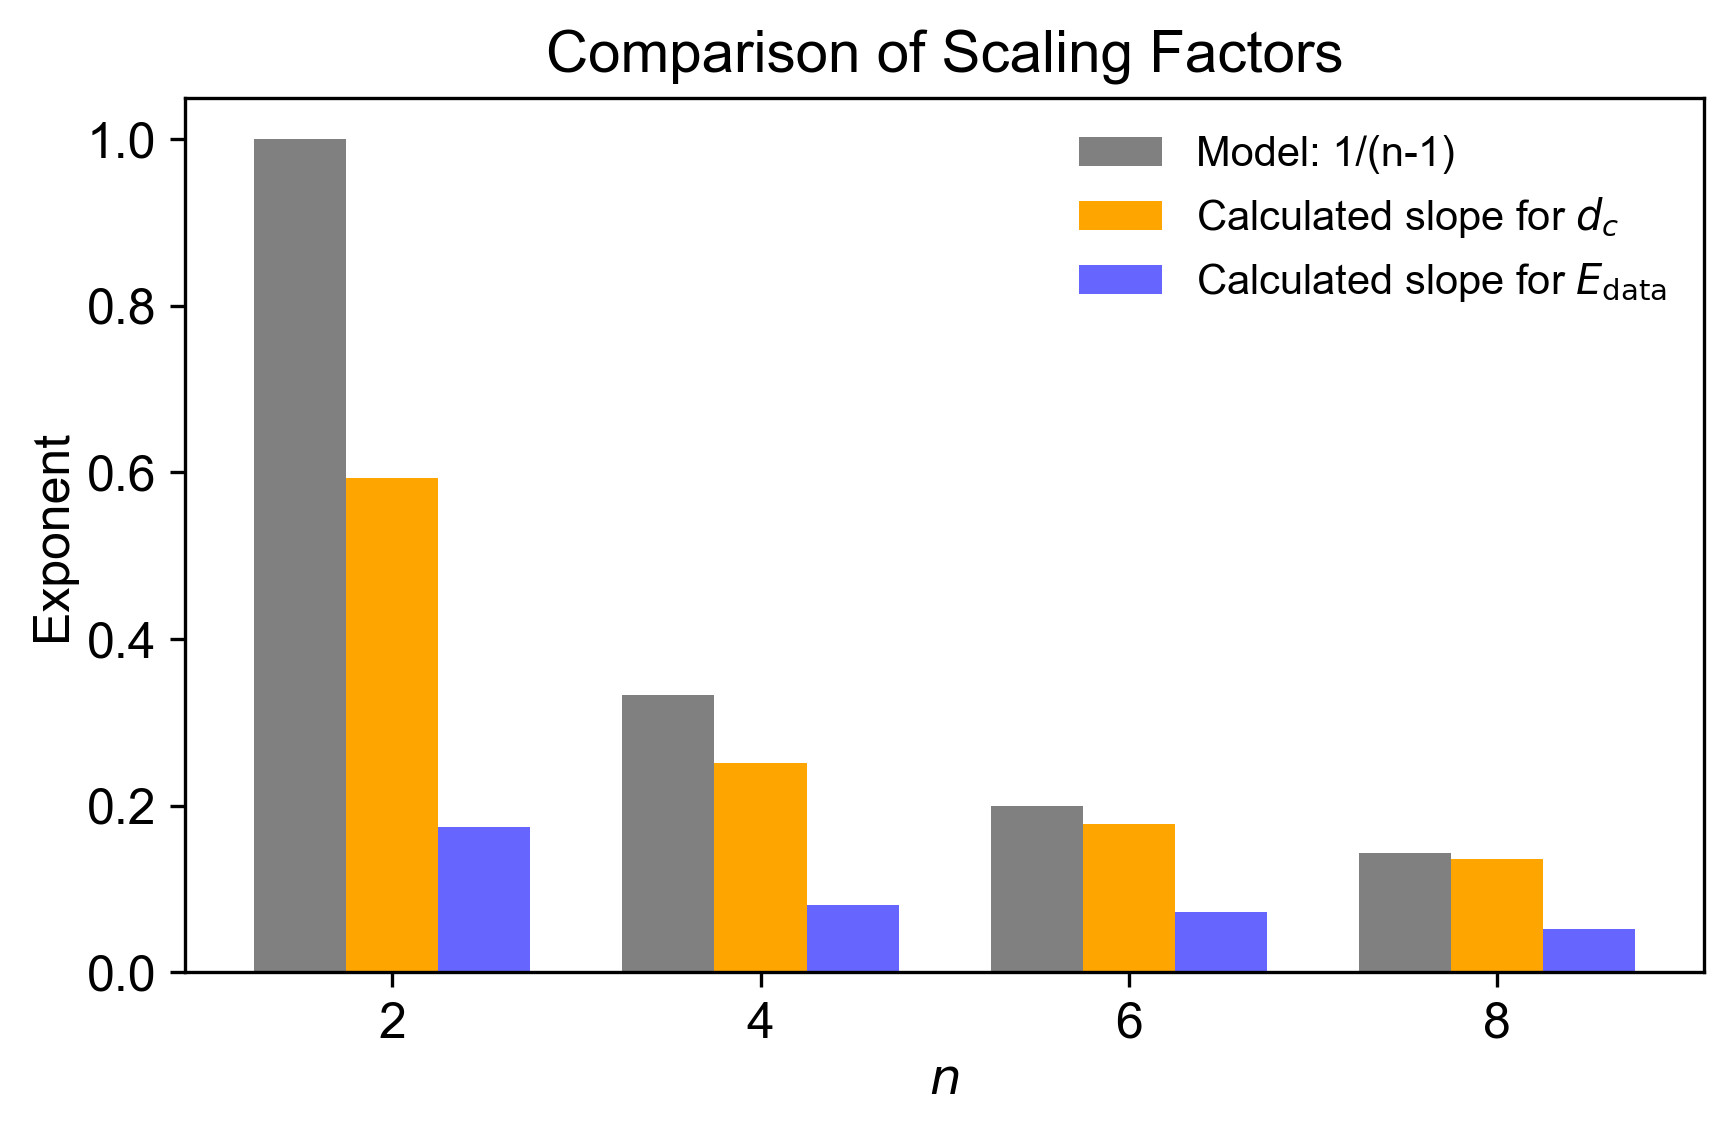

In [124]:
# scaling of data distance (comparison with expectation)

import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import linregress

k_d_list = [0.1, 1, 10, 100, 1000]
n_list = [2, 4, 6, 8]
noise_level = 0.1

calc_array = []
model_array = []

def calculate_regression(n_degree):
    dist_last_array = []
    energy_array = []
    
    for k_d in k_d_list:
        file_path = f"dat/v2/data_scale/k{k_d}_n{n_degree}_s{noise_level:.2f}".replace('.', '') + ".npz"
        data = np.load(file_path)
        dtdist = data['dtdist']
        dist_mean = dtdist.mean(axis=1)
        dist_last = dist_mean[-1]
        dist_last_array.append(dist_last)
        energy = data['energy'][-1,3] # data energy
        energy_array.append(energy)
        
    log_k_d = np.log10(k_d_list)
    log_d_c = np.log10(dist_last_array)
    log_energy = np.log10(energy_array)
    slope_d, intercept, r_value, p_value, std_err = linregress(log_k_d, log_d_c)
    slope_e, intercept, r_value, p_value, std_err = linregress(log_k_d, log_energy)
    
    return -slope_d, -slope_e

def scale_model(n_degree):
    return 1/(n_degree - 1)


for n_degree in n_list:
    calc_array.append(calculate_regression(n_degree))
    model_array.append(scale_model(n_degree))


calc_array = np.array(calc_array)  
model_array = np.array(model_array)


bar_width = 0.25
x_positions = np.arange(len(n_list))

plt.figure(figsize=(6, 4))

plt.bar(x_positions - bar_width, model_array, width=bar_width, label="Model: 1/(n-1)", color='grey')
plt.bar(x_positions, calc_array[:, 0], width=bar_width, label=r"Calculated slope for $d_c$", color='orange')
plt.bar(x_positions + bar_width, calc_array[:, 1], width=bar_width, label=r"Calculated slope for $E_\mathrm{data}$", color='blue', alpha=0.6)


# Add labels, title, and legend
plt.xlabel(r"$n$", fontsize=12)
plt.ylabel("Exponent", fontsize=12)
plt.title("Comparison of Scaling Factors", fontsize=14)
plt.xticks(x_positions, n_list)  # Set custom x-axis labels
plt.legend()
plt.tight_layout()
plt.savefig(f"figures/v2/data_scale/scale_s{noise_level:.2f}.".replace('.', ''), dpi=300, bbox_inches='tight')
plt.show()



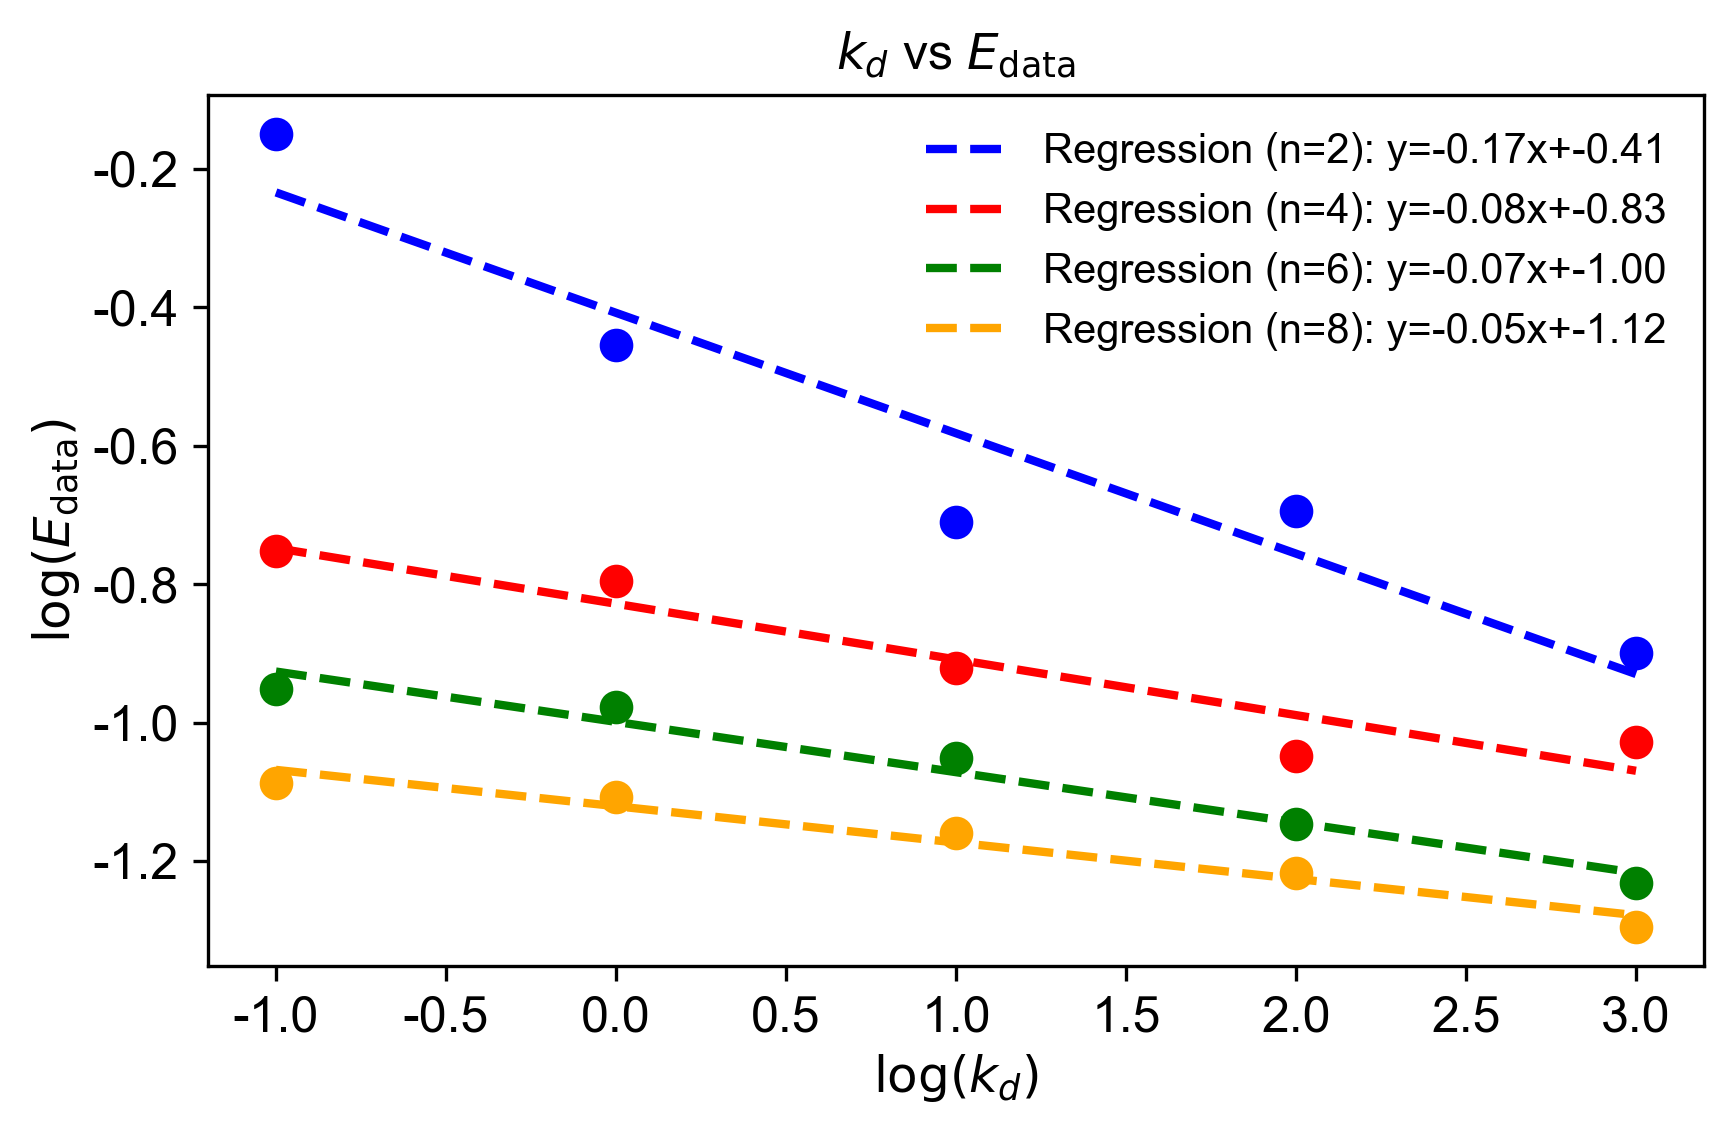

In [104]:
# k_d vs energy scale

import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import linregress

k_d_list = [0.1, 1, 10, 100, 1000]
noise_level = 0.1

def calculate_regression(n_degree):
    energy_array = []
    
    for k_d in k_d_list:
        file_path = f"dat/v2/data_scale/k{k_d}_n{n_degree}_s{noise_level:.2f}".replace('.', '') + ".npz"
        data = np.load(file_path)
        energy = data['energy'][-1,3] # data energy
        energy_array.append(energy)

    log_k_d = np.log10(k_d_list)
    log_energy = np.log10(energy_array)
    slope, intercept, r_value, p_value, std_err = linregress(log_k_d, log_energy)
    regression_line = slope * log_k_d + intercept
    
    return log_k_d, log_energy, regression_line, slope, intercept


log_k_d_2, log_d_c_2, regression_line_2, slope_2, intercept_2 = calculate_regression(n_degree=2)
log_k_d_4, log_d_c_4, regression_line_4, slope_4, intercept_4 = calculate_regression(n_degree=4)
log_k_d_6, log_d_c_6, regression_line_6, slope_6, intercept_6 = calculate_regression(n_degree=6)
log_k_d_8, log_d_c_8, regression_line_8, slope_8, intercept_8 = calculate_regression(n_degree=8)  


plt.figure(figsize=(6, 4))

# Plot data and regression for n_degree = 2
plt.scatter(log_k_d_2, log_d_c_2, color='blue', s=50)
plt.plot(log_k_d_2, regression_line_2, color='blue', linestyle='--', 
         label=f"Regression (n=2): y={slope_2:.2f}x+{intercept_2:.2f}")

# Plot data and regression for n_degree = 4
plt.scatter(log_k_d_4, log_d_c_4, color='red', s=50)
plt.plot(log_k_d_4, regression_line_4, color='red', linestyle='--', 
         label=f"Regression (n=4): y={slope_4:.2f}x+{intercept_4:.2f}")

# Plot data and regression for n_degree = 6
plt.scatter(log_k_d_6, log_d_c_6, color='green', s=50)
plt.plot(log_k_d_6, regression_line_6, color='green', linestyle='--', 
         label=f"Regression (n=6): y={slope_6:.2f}x+{intercept_6:.2f}")

# Plot data and regression for n_degree = 8
plt.scatter(log_k_d_8, log_d_c_8, color='orange', s=50)
plt.plot(log_k_d_8, regression_line_8, color='orange', linestyle='--', 
         label=f"Regression (n=8): y={slope_8:.2f}x+{intercept_8:.2f}")      

plt.xlabel(r"$\log(k_d)$", fontsize=12)
plt.ylabel(r"$\log(E_\mathrm{data})$", fontsize=12)
plt.title(r"$k_d$ vs $E_\mathrm{data}$", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(f"figures/v2/data_scale/kd_vs_energy_s{noise_level:.2f}.".replace('.', ''), dpi=300, bbox_inches='tight')
plt.show()



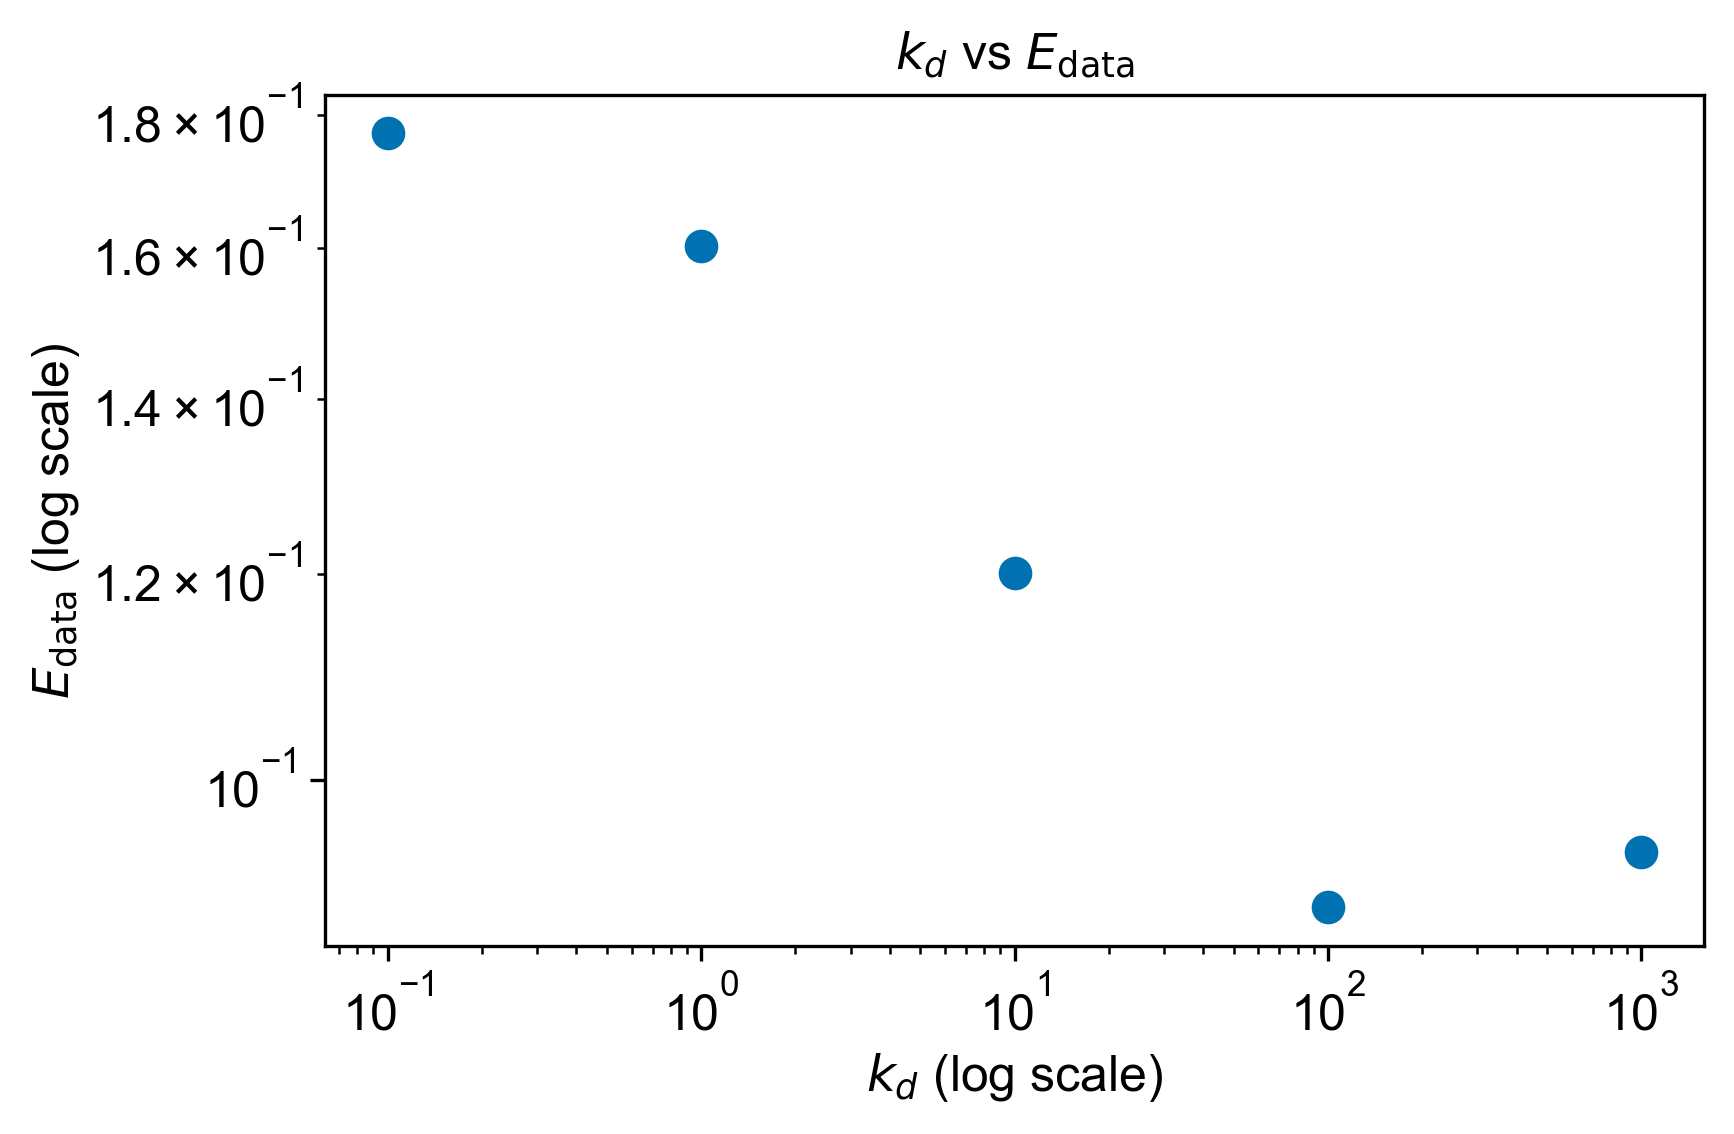

In [33]:
# k_d vs energy scale

import numpy as np
import matplotlib.pyplot as plt
import os

k_d_list = [0.1, 1, 10, 100, 1000]
n_degree = 4
noise_level = 0.1

energy_array = []

for k_d in k_d_list:

    file_path = f"dat/v2/data_scale/k{k_d}_n{n_degree}_s{noise_level:.2f}".replace('.', '') + ".npz"
    data = np.load(file_path)
    energy = data['energy']
    data_energy = energy[-1, 3]
    energy_array.append(data_energy)

plt.figure(figsize=(6, 4))

plt.scatter(k_d_list, energy_array, s=50)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"$k_d$ (log scale)", fontsize=12)
plt.ylabel(r"$E_\mathrm{data}$ (log scale)", fontsize=12)
plt.title(r"$k_d$ vs $E_\mathrm{data}$", fontsize=12)
# plt.legend()
plt.tight_layout()
# plt.savefig(f"figures/v2/data_scale/dist_k{k_d}_n{n_degree}_s{noise_level:.2f}.".replace('.', ''), dpi=300, bbox_inches='tight')
plt.show()

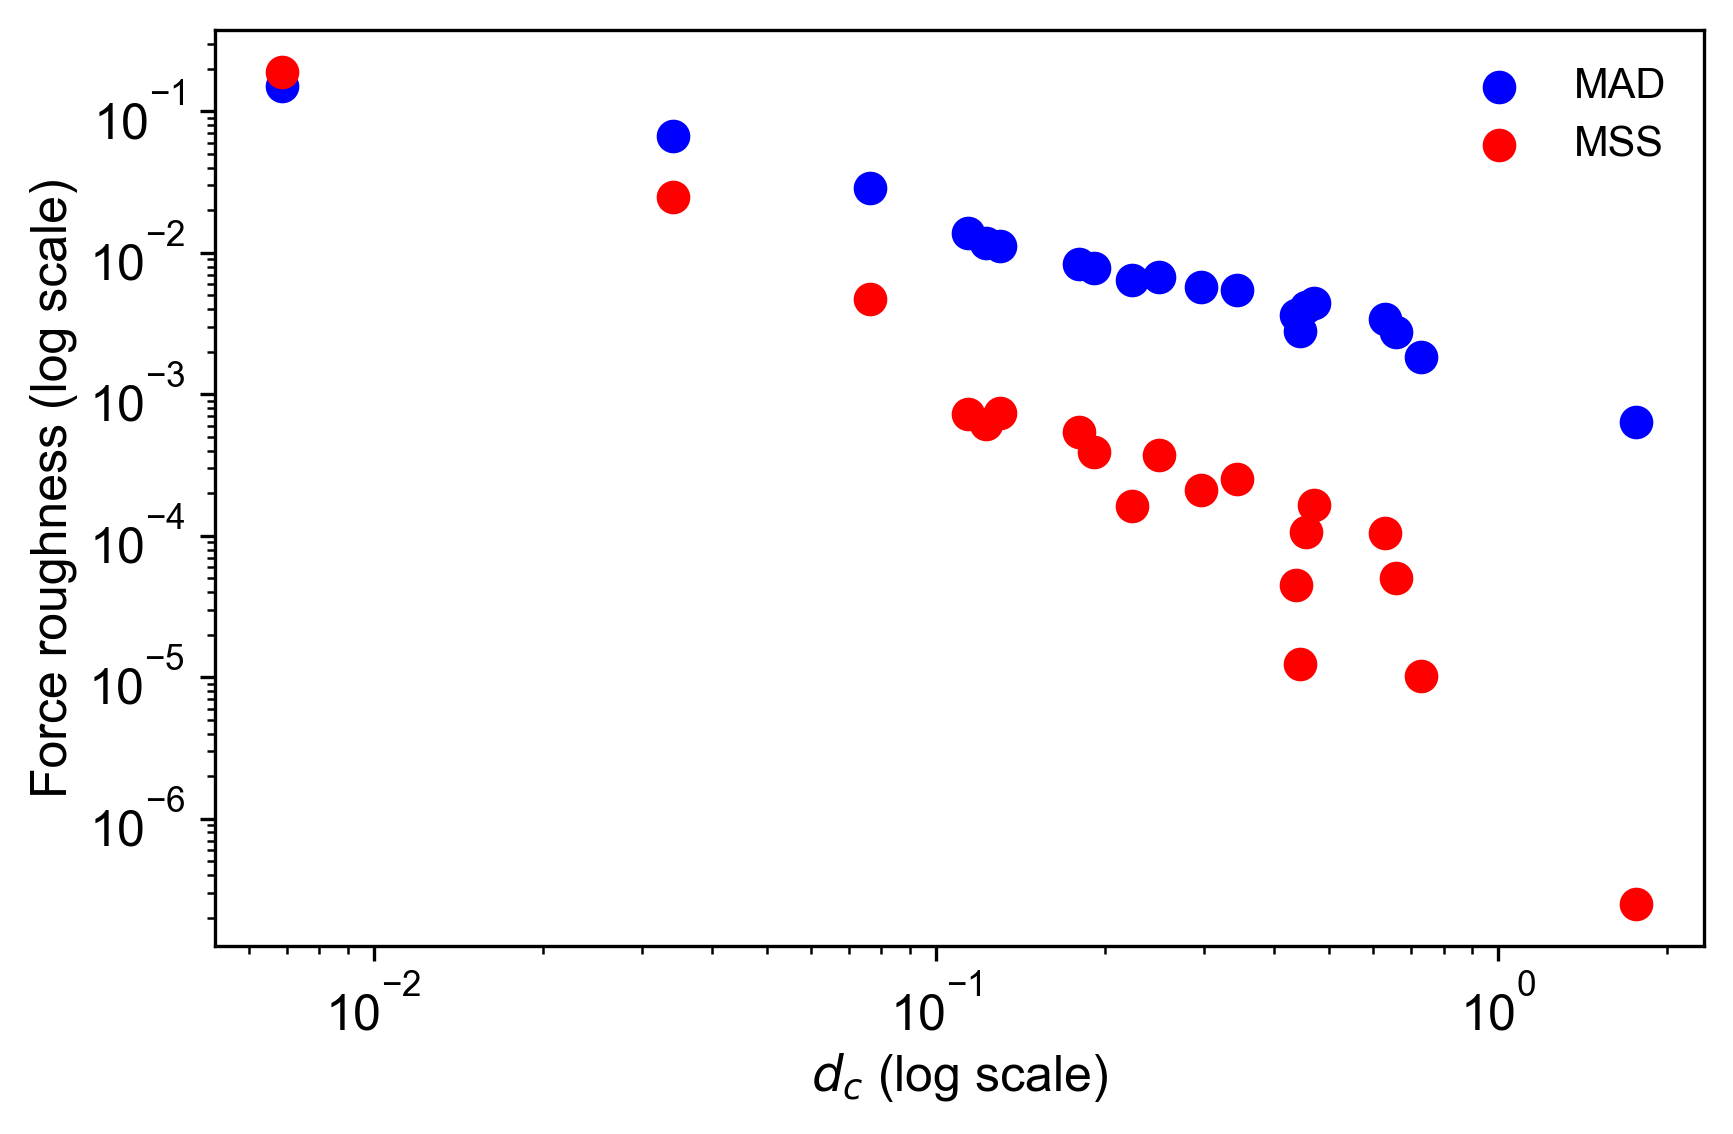

In [99]:
# Measurement of the smoothness of the force field

import numpy as np
import matplotlib.pyplot as plt
from automembrane.geometry import OpenPlaneCurveGeometry


k_d_list = [0.1, 1, 10, 100, 1000]
n_list = [2, 4, 6, 8]
# n_list = [8]
noise_level = 0.1
mad_array = []
mss_array = []
dist_array = []


def smoothness_measures(sequence):
    seq = np.array(sequence)
    # Mean Absolute Difference
    mad = np.mean(np.abs(np.diff(seq)))
    # Mean Squared Second Differences
    second_diff = seq[2:] - 2 * seq[1:-1] + seq[:-2]
    mss = np.mean(second_diff**2)
    return mad, mss

for n_degree in n_list:
    for k_d in k_d_list:
        
        file_path = f"dat/v2/data_scale/k{k_d}_n{n_degree}_s{noise_level:.2f}".replace('.', '') + ".npz"
        data = np.load(file_path)
        coords = data['coords'][-1]
        dtdist = np.mean(data['dtdist'][-1])
        # forces = np.sum(data['forces'][-1], axis=0)
        forces = data['forces'][-1,3] # data force
        normal = OpenPlaneCurveGeometry.vertex_normal(coords)
        dot_prod = np.sum(normal*forces, axis=1)

        mad, mss = smoothness_measures(dot_prod)
        mad_array.append(mad)
        mss_array.append(mss)
        dist_array.append(dtdist)


plt.figure(figsize=(6, 4))

plt.scatter(dist_array, mad_array, color='blue', label="MAD", s=50)
plt.scatter(dist_array, mss_array, color='red',  label="MSS", s=50)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r"$d_c$ (log scale)", fontsize=12)
plt.ylabel("Force roughness (log scale)", fontsize=12)
# plt.title(r"$k_d$ vs $d_c$", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(f"figures/v2/data_scale/roughness_s{noise_level:.2f}.".replace('.', ''), dpi=300, bbox_inches='tight')
plt.show()

